In [2]:
from typing import Iterator

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json

from torch.nn import Parameter
from torch.utils.data import TensorDataset, DataLoader

from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from sklearn.preprocessing import MinMaxScaler

In [3]:
from examples.case_studies.sc_GEM_analysis import load_data

expression_data, methylation_data, labels = load_data()

In [4]:
len(labels)

224

In [5]:
def remove_all_nan_columns(data, remove_all_zeros=True):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])

    if remove_all_zeros:
        # 删除全是0的列。
        valid_cols = ~np.all(data == 0, axis=0)
        data = data[:, valid_cols]
        print('After remove all zeros', data.shape[1])

    return data

In [6]:
expression_data_clean = remove_all_nan_columns(expression_data)
methylation_data_clean = remove_all_nan_columns(methylation_data)

Input #cols 59
After remove all nan 34
After remove all zeros 33
Input #cols 59
After remove all nan 27
After remove all zeros 27


Text(0.5, 1.0, 'methylation_data_clean')

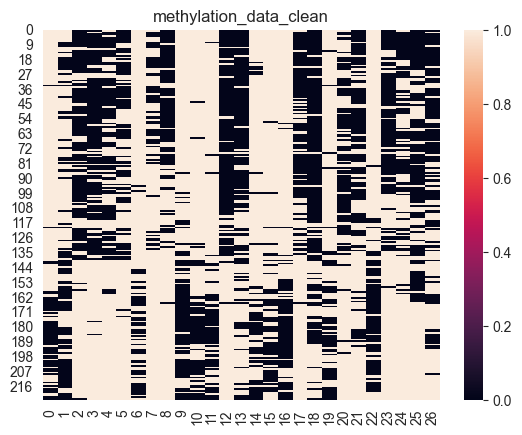

In [7]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

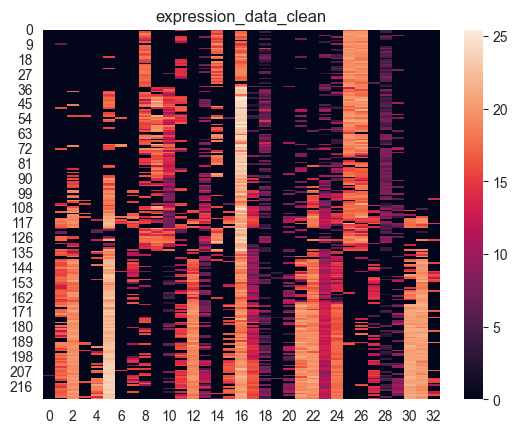

In [8]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [9]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(np.abs(data) > 1e-5)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [10]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [11]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((3023, 3), (3023,), (3782, 3), (3782,))

In [12]:
expression_edges.max(0), methylation_edges.max(0)

(array([223,  32,   0]), array([223,  59,   1]))

In [13]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [14]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [15]:
edges.shape, weights.shape

((6805, 3), (6805,))

In [16]:
np.any(weights == 0)

np.False_

In [17]:
save_edges_and_weights('./data/sc_GEM', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [18]:
train_data = np.load('./data/sc_GEM/train_data.npz', allow_pickle=True)
test_data = np.load('./data/sc_GEM/test_data.npz', allow_pickle=True)

In [19]:
train_data['nums_type']

array([224,  60,   2])

In [20]:
!mkdir -p ./embeddings/hgnn/sc_GEM

In [21]:
# !rm -rf ./*.npy && python3 hgnn/main_torch_zinb.py --data sc_GEM --feature adj --loss zinb --iter 50 && mv ./*.npy ./embeddings/hgnn/sc_GEM

## Analysis

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from hgnn.phasing import *

In [23]:
cell_embeddings = np.load('./embeddings/hgnn/sc_GEM/mymodel_0.npy', allow_pickle=True)
gene_embeddings = np.load('./embeddings/hgnn/sc_GEM/mymodel_1.npy', allow_pickle=True)
omic_embeddings = np.load('./embeddings/hgnn/sc_GEM/mymodel_2.npy', allow_pickle=True)


In [24]:
cell_embeddings.shape

(224, 64)

{'NMI': 0.6562888384366029,
 'ARI': 0.5128857835204764,
 'FMI': 0.582318450327919}

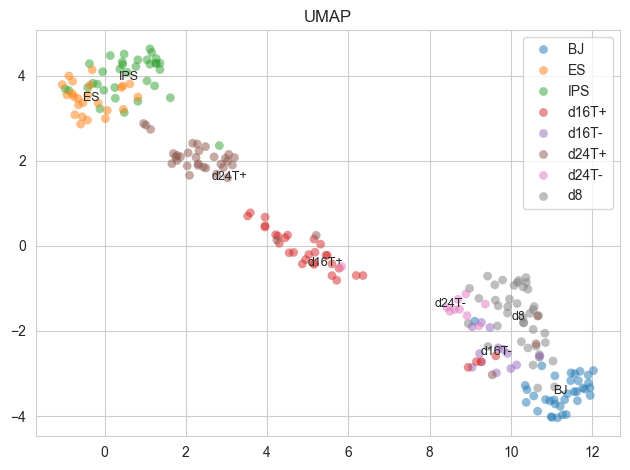

In [25]:
umap_visualize(cell_embeddings, labels)

## Phasing

In [26]:
G = torch.tensor(gene_embeddings, dtype=torch.float)
C = torch.tensor(cell_embeddings, dtype=torch.float)
O = torch.tensor(omic_embeddings, dtype=torch.float)
X = torch.tensor(np.concatenate([expression_data_clean, methylation_data_clean], axis=1), dtype=torch.float)

In [27]:
L = build_laplacian(C)

torch.trace(X.T @ L @ X)

tensor(120474.2500)

<Axes: >

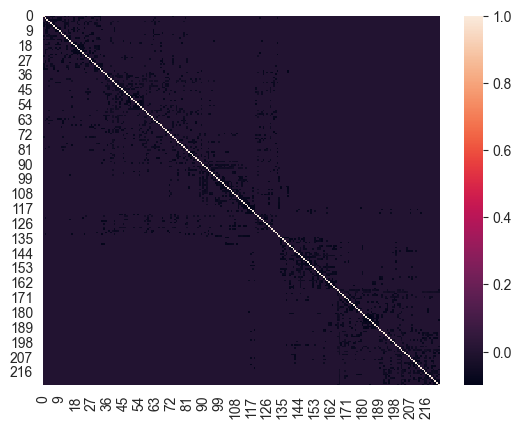

In [28]:
sns.heatmap(L)

In [29]:
np.min(np.linalg.eigvalsh(L))

np.float32(1.8636297e-09)

In [74]:
epochs = 5000
embed_dim = C.shape[1]
# 超参，按需要调
alpha = 0.001
k = 3
lr = 1e-3
omics_offset = expression_data_clean.shape[1]
num_cells = C.shape[0]
num_genes = G.shape[0]
embed_dim, omics_offset

(64, 33)

In [75]:
model, histories = train_phasing_model(
    embed_dim=embed_dim,
    omics_offset=omics_offset,
    epochs=epochs,
    lr=lr,
    k=k,
    alpha=alpha,
    C=C, G=G, O=O, X=X,
)

Epoch   0  total=853.815  rec=461.321  reg=392494.812
Epoch 100  total=71.442  rec=48.290  reg=23152.896
Epoch 200  total=52.253  rec=33.264  reg=18988.396
Epoch 300  total=46.715  rec=30.797  reg=15918.687
Epoch 400  total=44.267  rec=29.531  reg=14735.233
Epoch 500  total=42.720  rec=28.583  reg=14137.067
Epoch 600  total=41.472  rec=27.569  reg=13902.941
Epoch 700  total=39.997  rec=25.823  reg=14173.952
Epoch 800  total=38.699  rec=24.583  reg=14116.358
Epoch 900  total=37.563  rec=23.291  reg=14272.040
Epoch 1000  total=36.425  rec=22.106  reg=14318.951
Epoch 1100  total=35.550  rec=21.332  reg=14218.528
Epoch 1200  total=34.819  rec=20.694  reg=14124.410
Epoch 1300  total=34.119  rec=20.146  reg=13972.078
Epoch 1400  total=33.487  rec=19.698  reg=13789.191
Epoch 1500  total=32.950  rec=19.352  reg=13598.105
Epoch 1600  total=32.514  rec=19.090  reg=13423.569
Epoch 1700  total=32.151  rec=18.875  reg=13276.045
Epoch 1800  total=31.851  rec=18.686  reg=13164.730
Epoch 1900  total=3

Text(0.5, 1.0, 'Phasing Loss vs Epoch')

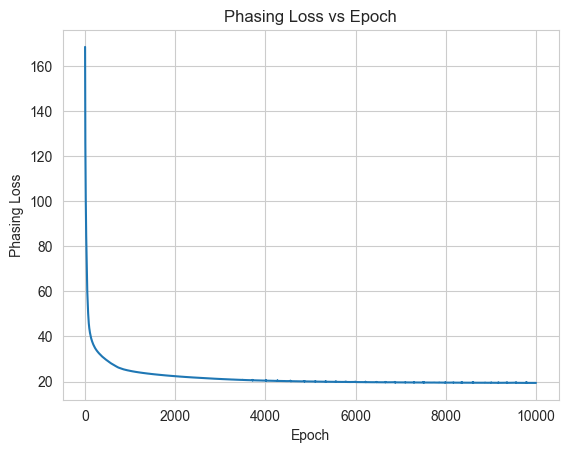

In [63]:
plt.plot(histories['history'])
plt.xlabel('Epoch')
plt.ylabel('Phasing Loss')
plt.title('Phasing Loss vs Epoch')

Text(0.5, 1.0, 'Reconstruction Loss vs Epoch')

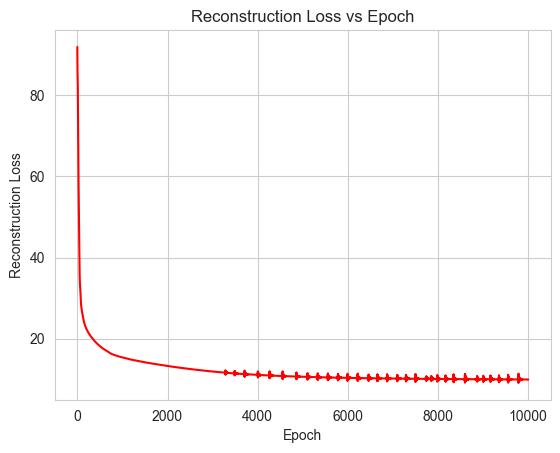

In [64]:
plt.plot(histories['history_recon'], color='red')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Reconstruction Loss vs Epoch')

Text(0.5, 1.0, 'Regularization Loss vs Epoch')

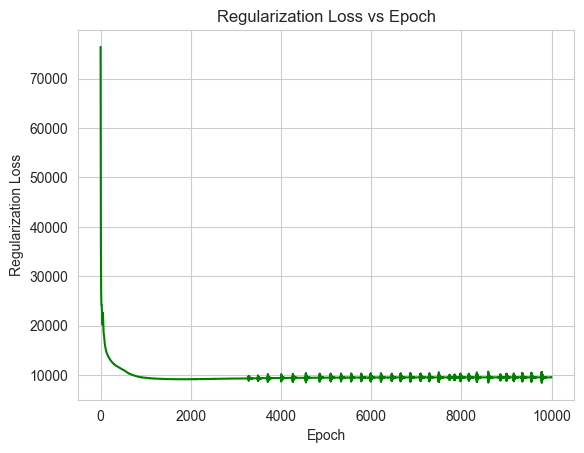

In [65]:
plt.plot(histories['history_reg'], color='green')
plt.xlabel('Epoch')
plt.ylabel('Regularization Loss')
plt.title('Regularization Loss vs Epoch')

In [81]:
Xp0, Xp1, Xm0, Xm1 = model.predict(G, C, O)
# Xp1 = (Xp1 > 0.5).astype(bool)
# Xm1 = (Xm1 > 0.5).astype(bool)

Text(0.5, 1.0, 'X1')

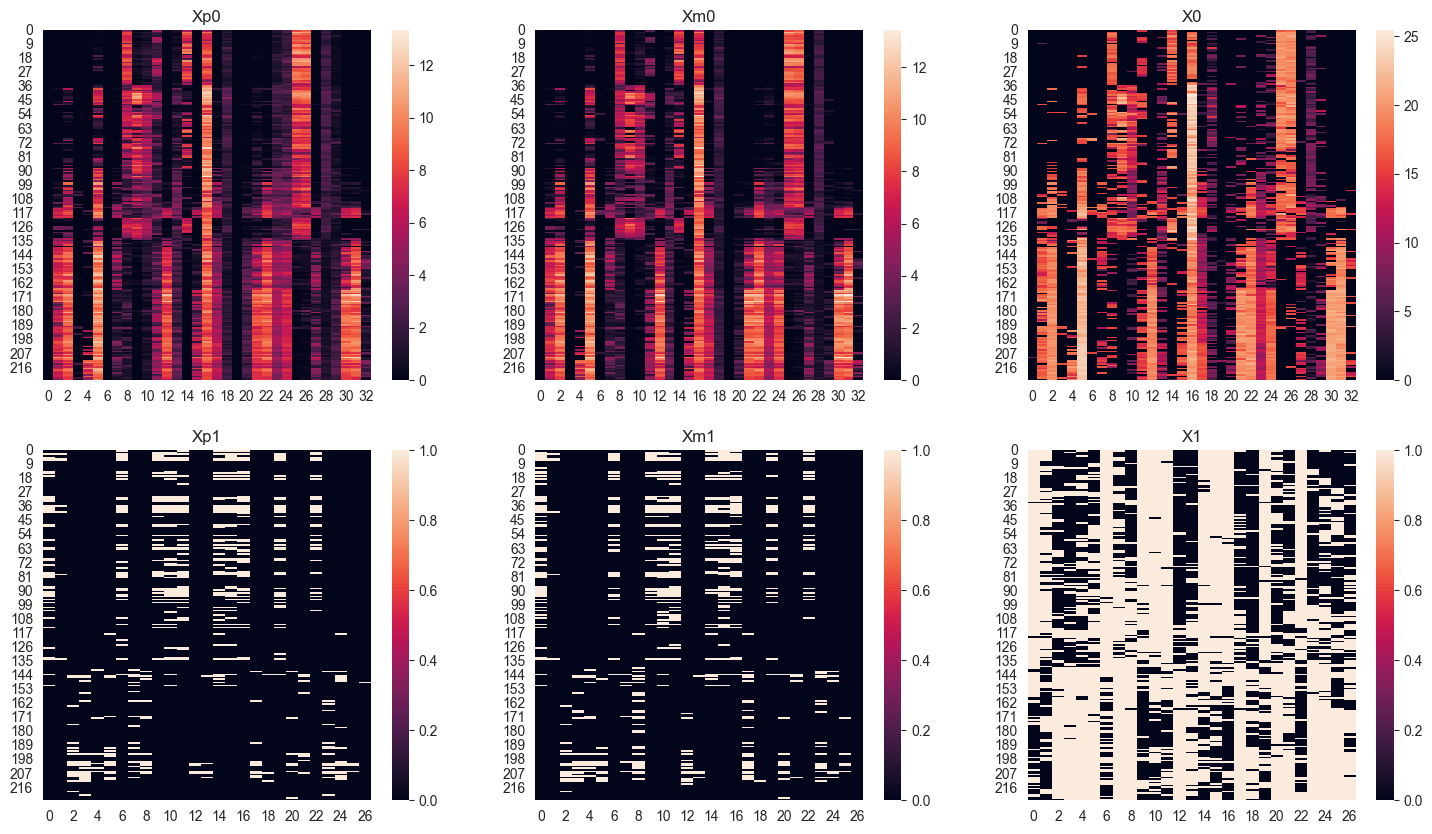

In [76]:
plt.figure(figsize=(18,10))
ax = plt.subplot(231)
sns.heatmap(Xp0,ax=ax)
plt.title('Xp0')
ax = plt.subplot(232)
sns.heatmap(Xm0,ax=ax)
plt.title('Xm0')
ax = plt.subplot(233)
sns.heatmap(expression_data_clean,ax=ax)
plt.title('X0')
ax = plt.subplot(234)
sns.heatmap(Xp1,ax=ax)
plt.title('Xp1')
ax = plt.subplot(235)
sns.heatmap(Xm1,ax=ax)
plt.title('Xm1')
ax = plt.subplot(236)
sns.heatmap(methylation_data_clean,ax=ax)
plt.title('X1')

{'NMI': 0.6358525846018627,
 'ARI': 0.4992465353721724,
 'FMI': 0.5665950011732004}

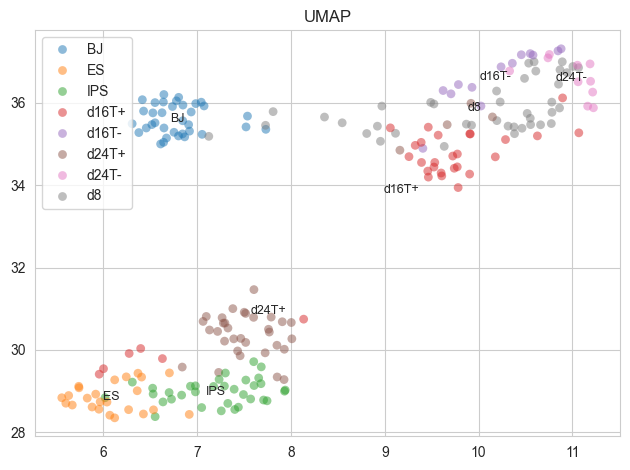

In [85]:
umap_visualize(X, labels)

{'NMI': 0.6563335928020476,
 'ARI': 0.5214315265099865,
 'FMI': 0.5891462398256873}

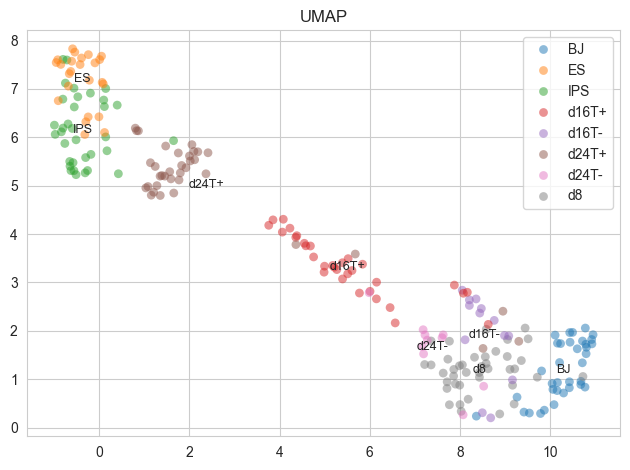

In [37]:
umap_visualize(C, labels)

{'NMI': 0.6602146392039149,
 'ARI': 0.5703117793070801,
 'FMI': 0.6296599710872957}

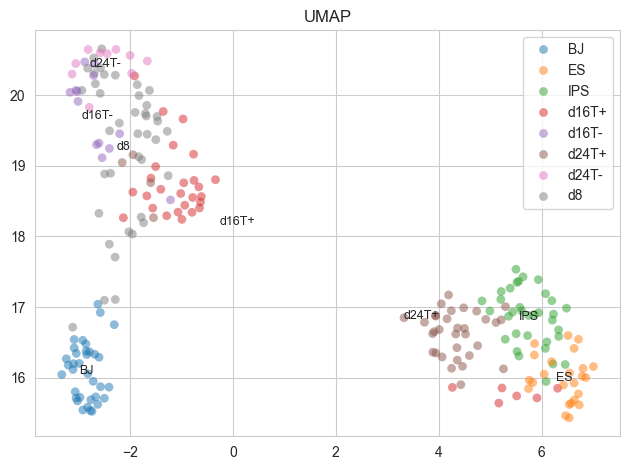

In [72]:
umap_visualize(expression_data_clean, labels)

{'NMI': 0.617519120619091,
 'ARI': 0.48128344868882844,
 'FMI': 0.5535856956026022}

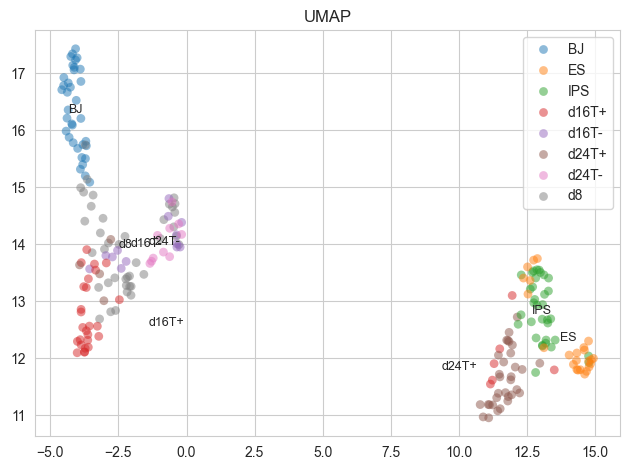

In [77]:
umap_visualize(Xp0, labels)


{'NMI': 0.6043689148178705,
 'ARI': 0.44770391660657616,
 'FMI': 0.5219971400241851}

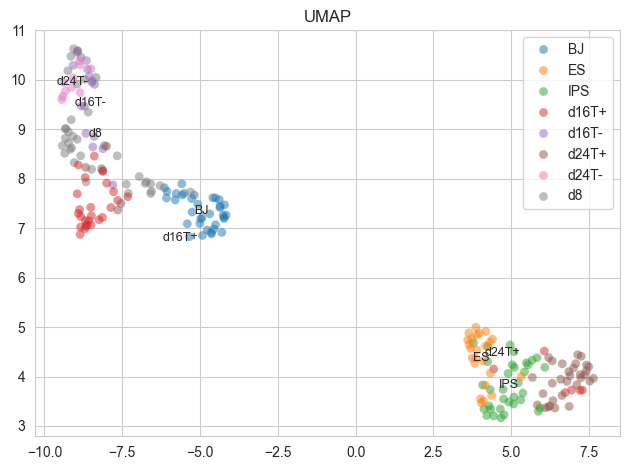

In [78]:
umap_visualize(Xm0, labels)


{'NMI': 0.3739407493928559,
 'ARI': 0.19497838369759993,
 'FMI': 0.3066939140452285}

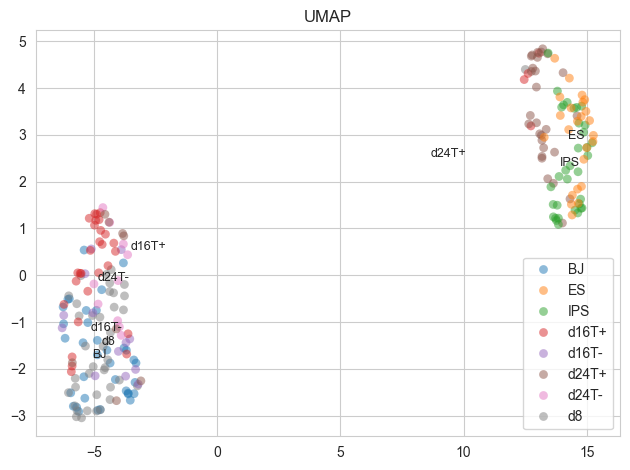

In [82]:
umap_visualize(Xp1, labels)


{'NMI': 0.3775469679031029,
 'ARI': 0.18833260521972495,
 'FMI': 0.2981501755505424}

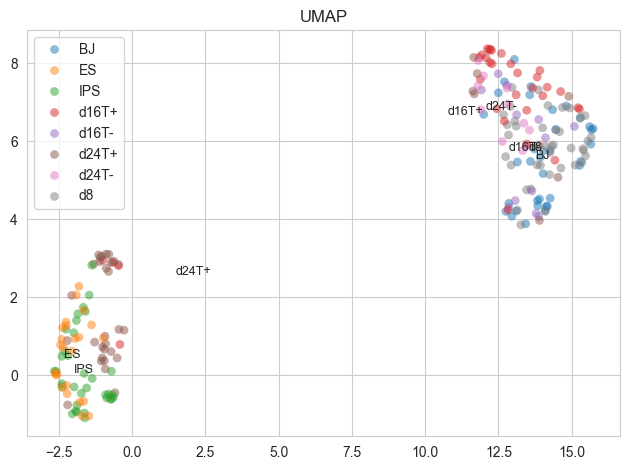

In [83]:
umap_visualize(Xm1, labels)


{'NMI': 0.38202491373413505,
 'ARI': 0.235258321475829,
 'FMI': 0.3437285100919121}

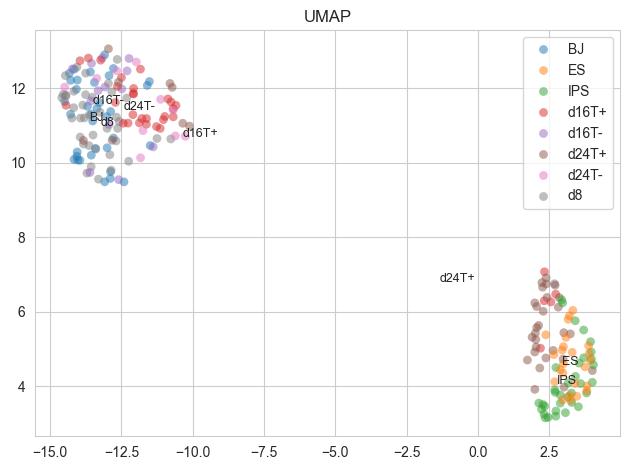

In [84]:
umap_visualize(methylation_data_clean, labels)